# 16.4.1 布朗增量与 Euler–Maruyama

## 学习目标与先修知识

用固定增量实现稳态偏差的随机恢复，并区分噪声幅度随步长的缩放。

先修：5.4 随机过程（stochastic process）；2.4 Euler；7.3 噪声。

## 具体问题

时间步缩小一半，随机输入（input）的典型增量应跟步长还是步长的平方根缩小？粗细路径怎样共享同一随机驱动？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
h=.04;z=np.array([-1.,.5,1.]);print("由标准正态数构造的布朗增量：",np.sqrt(h)*z)

由标准正态数构造的布朗增量： [-0.2  0.1  0.2]


## 模型假设

X 是相对参考水平的偏差，而非必须非负的物质总量；例如 $X=-0.2$ U 表示比参考水平低 0.2 U，并非存在负物质。Itô 方程 $dX=-aX\,dt+\sigma\,dW$；$a$ 单位1/T，$\sigma$ 单位 U/√T，$dW$ 单位√T。函数输入已经是固定布朗增量，不在函数内部重新抽样；粗增量由对应细增量求和。

## 数学解释与推导

布朗运动独立增量满足 $E[\Delta W]=0$、$\operatorname{Var}(\Delta W)=h$。Euler–Maruyama 更新 $X_{n+1}=X_n-a h X_n+\sigma\Delta W_n$；若给标准正态 $Z_n$，则 $\Delta W_n=\sqrt h Z_n$。同路径粗细比较必须将细增量按块相加；另抽粗噪声只能比较分布（distribution），不能计算路径配对误差。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def em_path(x0,a,sigma,h,increments):
    state=float(x0);path=[state]
    for dw in increments:
        state=state-a*h*state+sigma*dw
        path.append(float(state))
    return path


def merge_brownian(increments,block):
    return [float(sum(increments[i:i+block]))
            for i in range(0,len(increments),block)]


def ou_moments(x0,a,sigma,time):
    mean=x0*math.exp(-a*time)
    variance=sigma*sigma*time if a==0 else sigma*sigma*(-math.expm1(-2*a*time))/(2*a)
    return [float(mean),float(variance)]

## 对照实验

把每四个细步布朗增量相加成一个粗步增量，使两条轨迹（trajectory）共享底层随机路径，再比较终点差。

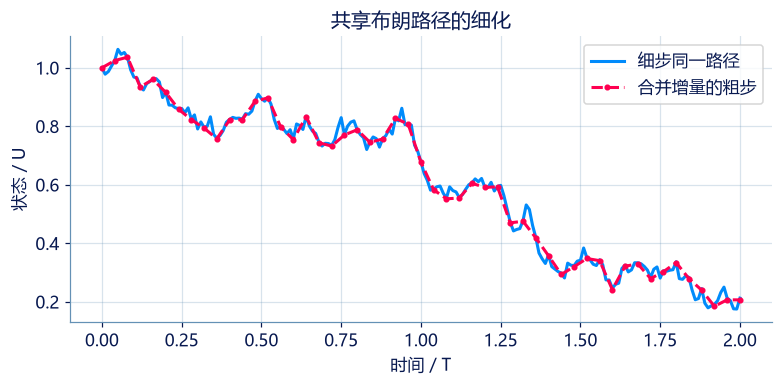

终点配对差： 0.005990318502200609 ；解析均值与方差： [0.2465969639416065, 0.041928122204231345]


In [4]:
rng=np.random.default_rng(16);h=.01;fine_dw=np.sqrt(h)*rng.normal(size=200);coarse_dw=merge_brownian(fine_dw,4)
fine=np.asarray(em_path(1.,.7,.25,h,fine_dw));coarse=np.asarray(em_path(1.,.7,.25,4*h,coarse_dw))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(np.arange(len(fine))*h,fine,label="细步同一路径",color=BLUE);ax.plot(np.arange(len(coarse))*4*h,coarse,"o--",label="合并增量的粗步",color=PINK,ms=3);ax.set(xlabel="时间 / T",ylabel="状态 / U",title="共享布朗路径的细化");ax.legend();ax.grid(alpha=.25);plt.show()
print("终点配对差：",abs(fine[-1]-coarse[-1]),"；解析均值与方差：",ou_moments(1.,.7,.25,2.))

## 结果解释

两条轨迹（trajectory）共享同一底层增量，终点差包含数值离散误差。下一节用独立重复计算均值、方差（variance）和越界频率。这里的状态（state）是可正可负的偏差，计算保留其原始值。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(sum(fine_dw),sum(coarse_dw))
assert len(coarse_dw)==50 and len(fine)==201
np.testing.assert_allclose(ou_moments(1.,0.,.25,2.),[1.,.125])
print("增量合并、步数与零漂移解析矩核验通过。")

增量合并、步数与零漂移解析矩核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：随机增量的尺度

给标准正态 Z，长度 h 的布朗增量应如何生成？

- **A.** sqrt(h)*Z。
- **B.** h*Z。
- **C.** Z/h。
- **D.** 每步固定为 h。

[作答：随机增量的尺度](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-brownian-scale)

### 第 2 题 · 单项选择题：同路径粗细比较

给定细网格布朗增量，构造对应粗路径的增量应怎样？

- **A.** 重新独立抽样。
- **B.** 按粗步覆盖的细增量求和。
- **C.** 取细增量均值。
- **D.** 删除所有负增量。

[作答：同路径粗细比较](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-paired-refine)

### 第 3 题 · Python 计算题：固定随机增量的 Euler–Maruyama

对 OU 方程 dX=-aXdt+σdW 按给定布朗增量推进；函数不再自行抽样。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    sigma: float,
    h: float,
    increments: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `a` | `float` | 恢复率。 | 1/T |
| `sigma` | `float` | 噪声幅度。 | U/√T |
| `h` | `float` | 步长。 | T |
| `increments` | `list[float]` | 按步给定的布朗增量。 | √T |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初态的路径。 | U |

**计算规则**

按给定布朗增量逐步计算 x_next=x-a*h*x+sigma*dw；不在函数内重新抽样。

**约束与边界**

- a≥0、sigma≥0、h>0；增量长度≤100且所有输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 1 | U |
| a | 恢复率。 | 1 | 1/T |
| sigma | 噪声幅度。 | 0.5 | U/√T |
| h | 步长。 | 0.1 | T |
| increments | 按步给定的布朗增量。 | [0.2, -0.1] | √T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
a = 1.0
sigma = 0.5
h = 0.1
increments = [0.2, -0.1]

result = solve(x0, a, sigma, h, increments)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初态的路径。 | [1.0, 1.0, 0.85] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 1.0, 0.85]
```

**样例解释**

首步 1-0.1+0.5×0.2=1.0；固定增量便于逐项复核。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定随机增量的 Euler–Maruyama](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-em-increments)

### 第 4 题 · Python 计算题：粗细网格共用同一路径

把细网格布朗增量每 block 项求和，形成粗网格的对应增量。

**函数与代码模板**

```python
def solve(
    increments: list[float],
    block: int,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `increments` | `list[float]` | 细网格布朗增量。 | √T |
| `block` | `int` | 每个粗步包含的细步数。 | 步 |

**返回值**

直接返回 merged（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `merged` | `list[float]` | 逐块求和后的增量。 | √T |

**计算规则**

按 block 个连续细增量求和；输入（input）长度能被 block 整除。

**约束与边界**

- block 为正整数，增量长度≤100 且可被 block 整除；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| increments | 细网格布朗增量。 | [0.1, -0.2, 0.3, 0.4] | √T |
| block | 每个粗步包含的细步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
increments = [0.1, -0.2, 0.3, 0.4]
block = 2

result = solve(increments, block)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| merged | 逐块求和后的增量。 | [-0.1, 0.7] | √T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-0.1, 0.7]
```

**样例解释**

首例两个粗步的增量分别为 -0.1 和0.7；求和而非平均。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：粗细网格共用同一路径](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-brownian-merge)

**进一步阅读**

[Higham 的 SDE 数值教程](https://epubs.siam.org/doi/10.1137/S0036144500378302)讨论 Euler–Maruyama 及强、弱误差。